## Step 1  Environment Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder
)

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

### Professional Plot Style

In [2]:
plt.rcParams['figure.facecolor'] = '#f5f5f5'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

sns.set_style("whitegrid")

### Load Dataset

In [3]:
dataset_path = "/kaggle/input/datasets/waqarokzi/house-prices-advanced-regression-techniques/train.csv"

df = pd.read_csv(dataset_path)

### Basic Information

In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1460, 81)


In [5]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64 

In [6]:
print("\nDataset Description:")
print(df.describe())


Dataset Description:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.0

### Identify Numerical & Categorical Columns

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [8]:
print("\nNumber of Numerical Columns:", len(numerical_cols))
print(numerical_cols)


Number of Numerical Columns: 38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [9]:
print("\nNumber of Categorical Columns:", len(categorical_cols))
print(categorical_cols)


Number of Categorical Columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


### Top Correlated Features with SalePrice

In [10]:
corr_with_price = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Correlated Features with SalePrice:")
print(corr_with_price)


Top 10 Correlated Features with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


## Step 2  Matplotlib Chart 1 & 2 (Distribution Analysis)

### STEP 2 DISTRIBUTION ANALYSIS

### Chart 1  SalePrice Distribution

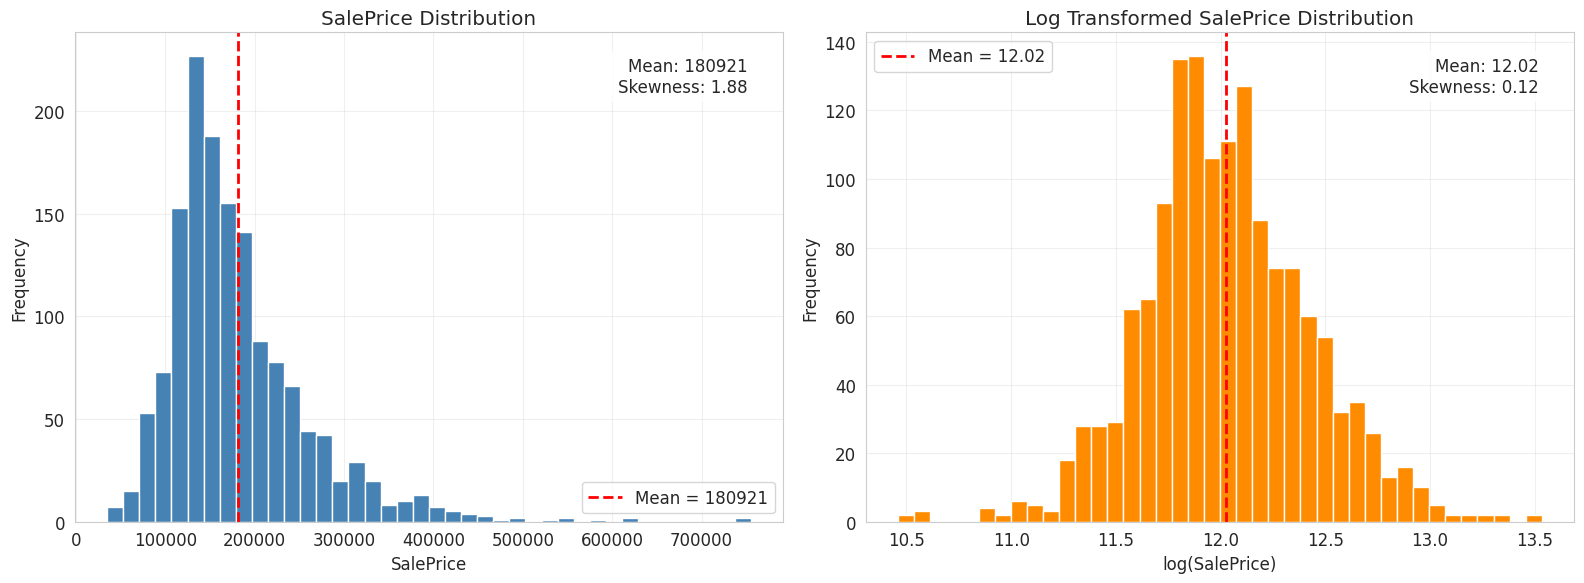

In [11]:
saleprice_mean = df['SalePrice'].mean()
saleprice_skew = df['SalePrice'].skew()

log_saleprice = np.log1p(df['SalePrice'])

log_mean = log_saleprice.mean()
log_skew = log_saleprice.skew()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot — Original SalePrice
axes[0].hist(
    df['SalePrice'],
    bins=40,
    color='steelblue',
    edgecolor='white'
)

axes[0].axvline(
    saleprice_mean,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {saleprice_mean:.0f}'
)

axes[0].set_title("SalePrice Distribution")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")

axes[0].text(
    0.95,
    0.95,
    f"Mean: {saleprice_mean:.0f}\nSkewness: {saleprice_skew:.2f}",
    transform=axes[0].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

axes[0].legend()

# Right Plot — Log Transformed SalePrice
axes[1].hist(
    log_saleprice,
    bins=40,
    color='darkorange',
    edgecolor='white'
)

axes[1].axvline(
    log_mean,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {log_mean:.2f}'
)

axes[1].set_title("Log Transformed SalePrice Distribution")
axes[1].set_xlabel("log(SalePrice)")
axes[1].set_ylabel("Frequency")

axes[1].text(
    0.95,
    0.95,
    f"Mean: {log_mean:.2f}\nSkewness: {log_skew:.2f}",
    transform=axes[1].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

axes[1].legend()

plt.tight_layout()

plt.savefig("w3_saleprice_distribution.png", dpi=150)

plt.show()

### Chart 2 GrLivArea Distribution

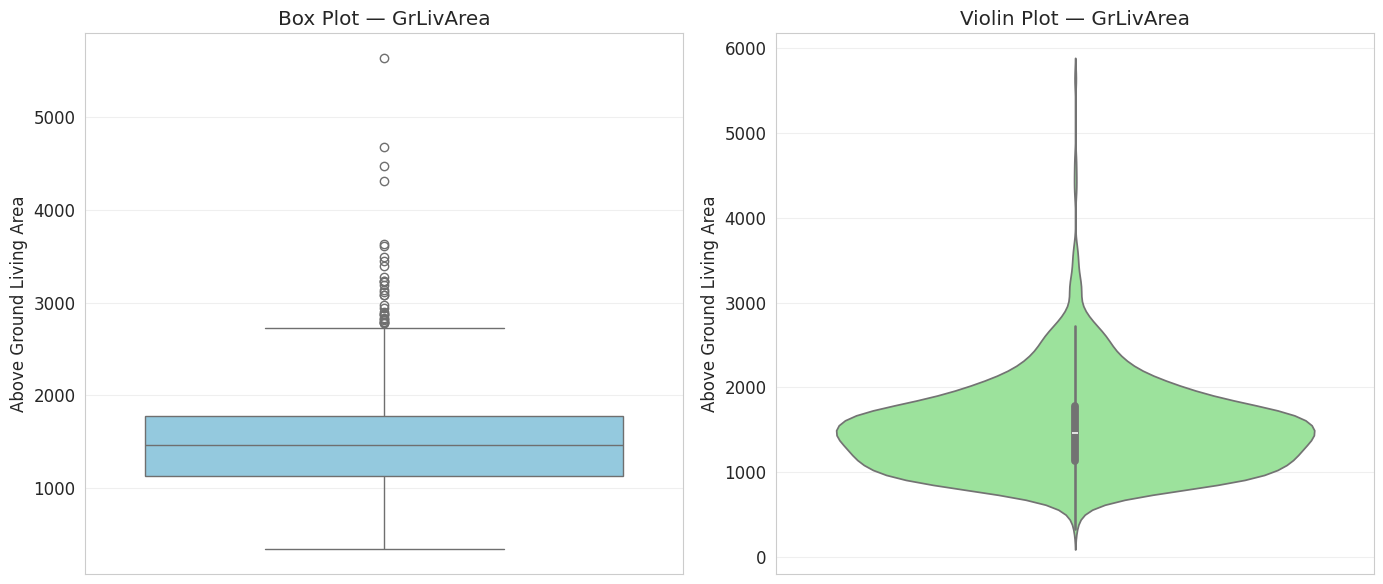

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot
sns.boxplot(
    y=df['GrLivArea'],
    color='skyblue',
    ax=axes[0]
)

axes[0].set_title("Box Plot — GrLivArea")
axes[0].set_ylabel("Above Ground Living Area")

# Violin Plot
sns.violinplot(
    y=df['GrLivArea'],
    color='lightgreen',
    ax=axes[1]
)

axes[1].set_title("Violin Plot — GrLivArea")
axes[1].set_ylabel("Above Ground Living Area")

plt.tight_layout()

plt.savefig("w3_grlivarea_distribution.png", dpi=150)

plt.show()

## Step 3 Multi-Variable Scatter Plot

###  MULTI VARIABLE SCATTER PLOT

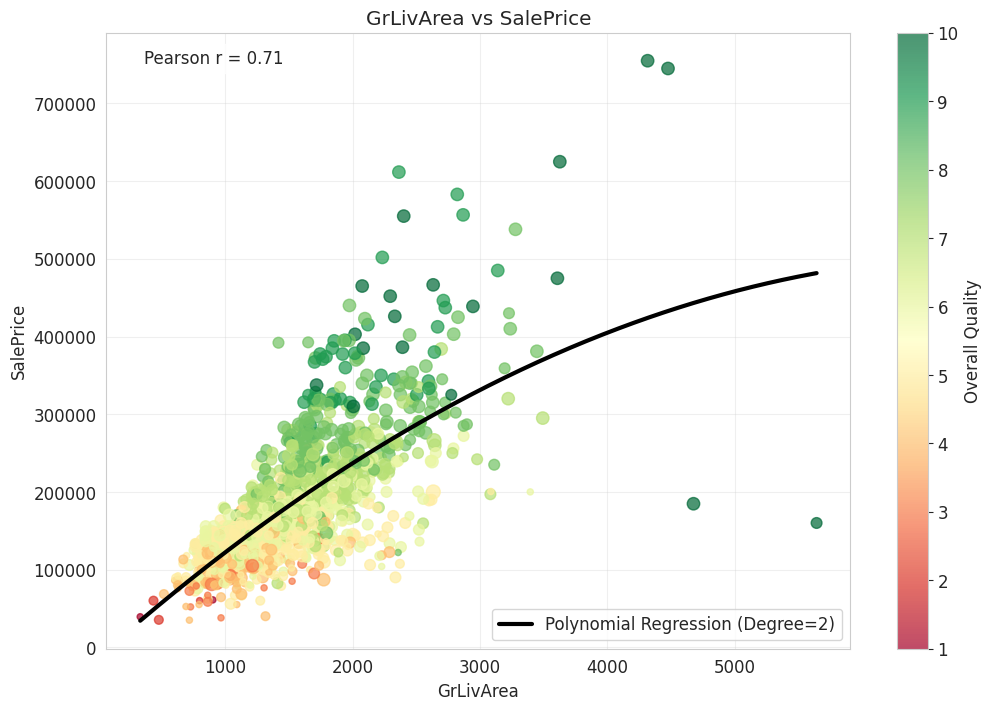

In [13]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df['GrLivArea'],
    df['SalePrice'],
    c=df['OverallQual'],
    cmap=plt.cm.RdYlGn,
    s=df['GarageCars'] * 20 + 20,
    alpha=0.7
)

# Polynomial Regression Line
x = df['GrLivArea']
y = df['SalePrice']

coefficients = np.polyfit(x, y, 2)
poly = np.poly1d(coefficients)

x_line = np.linspace(x.min(), x.max(), 500)

plt.plot(
    x_line,
    poly(x_line),
    color='black',
    linewidth=3,
    label='Polynomial Regression (Degree=2)'
)

# Correlation
corr = df['GrLivArea'].corr(df['SalePrice'])

plt.text(
    0.05,
    0.95,
    f'Pearson r = {corr:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8)
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Overall Quality')

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")

plt.legend()

plt.show()

### This scatter plot visualizes four variables simultaneously:

1. GrLivArea is represented on the x-axis.
2. SalePrice is represented on the y-axis.
3. OverallQual is encoded using color intensity via the RdYlGn colormap.
4. GarageCars is represented through marker size.

Additionally, a polynomial regression line captures the nonlinear relationship between living area and sale price, while the Pearson correlation coefficient quantifies the strength of the relationship.

## Step 4 Time-Based Trend Analysis

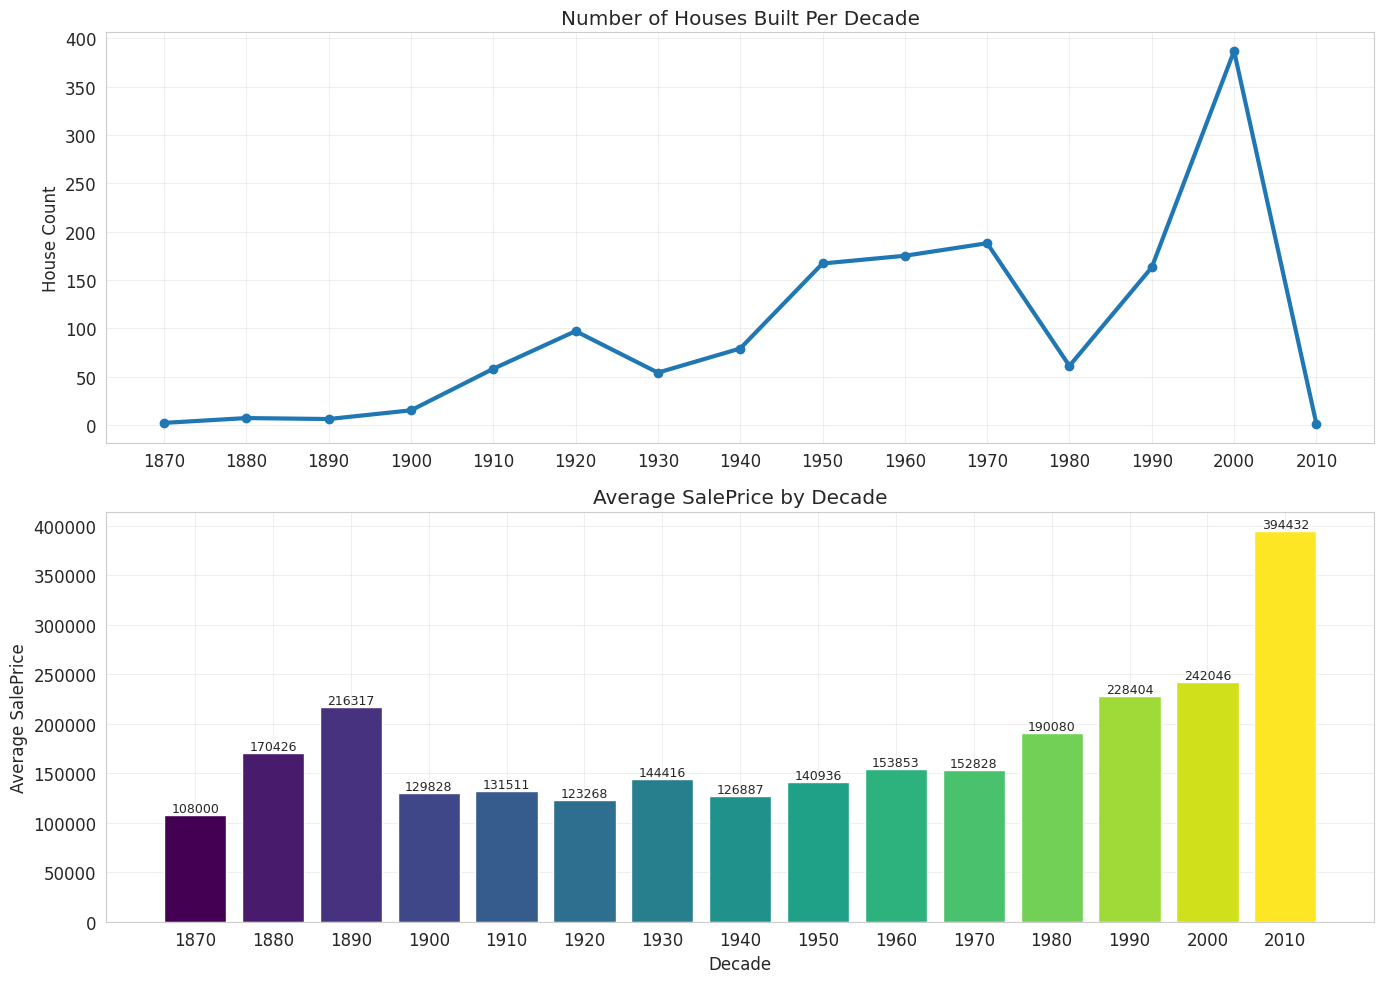

In [14]:
# ============================================
# STEP 4 — TIME BASED TREND ANALYSIS
# ============================================

# Create Decade Column
df['DecadeBuilt'] = (df['YearBuilt'] // 10) * 10

# Count of Houses Per Decade
decade_counts = df['DecadeBuilt'].value_counts().sort_index()

# Average SalePrice Per Decade
avg_price_decade = df.groupby('DecadeBuilt')['SalePrice'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --------------------------------------------
# Line Chart
# --------------------------------------------

axes[0].plot(
    decade_counts.index.astype(str),
    decade_counts.values,
    marker='o',
    linewidth=3
)

axes[0].set_title("Number of Houses Built Per Decade")
axes[0].set_ylabel("House Count")

# --------------------------------------------
# Bar Chart
# --------------------------------------------

colors = plt.cm.viridis(
    np.linspace(0, 1, len(avg_price_decade))
)

bars = axes[1].bar(
    avg_price_decade.index.astype(str),
    avg_price_decade.values,
    color=colors
)

axes[1].set_title("Average SalePrice by Decade")
axes[1].set_ylabel("Average SalePrice")

# Value Labels
for bar in bars:
    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Decade")

plt.tight_layout()

plt.savefig("w3_time_trend.png", dpi=150)

plt.show()

## Step 5 Seaborn Charts 5 & 6

### Chart 5  Boxplot

/tmp/ipykernel_57/3493102464.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


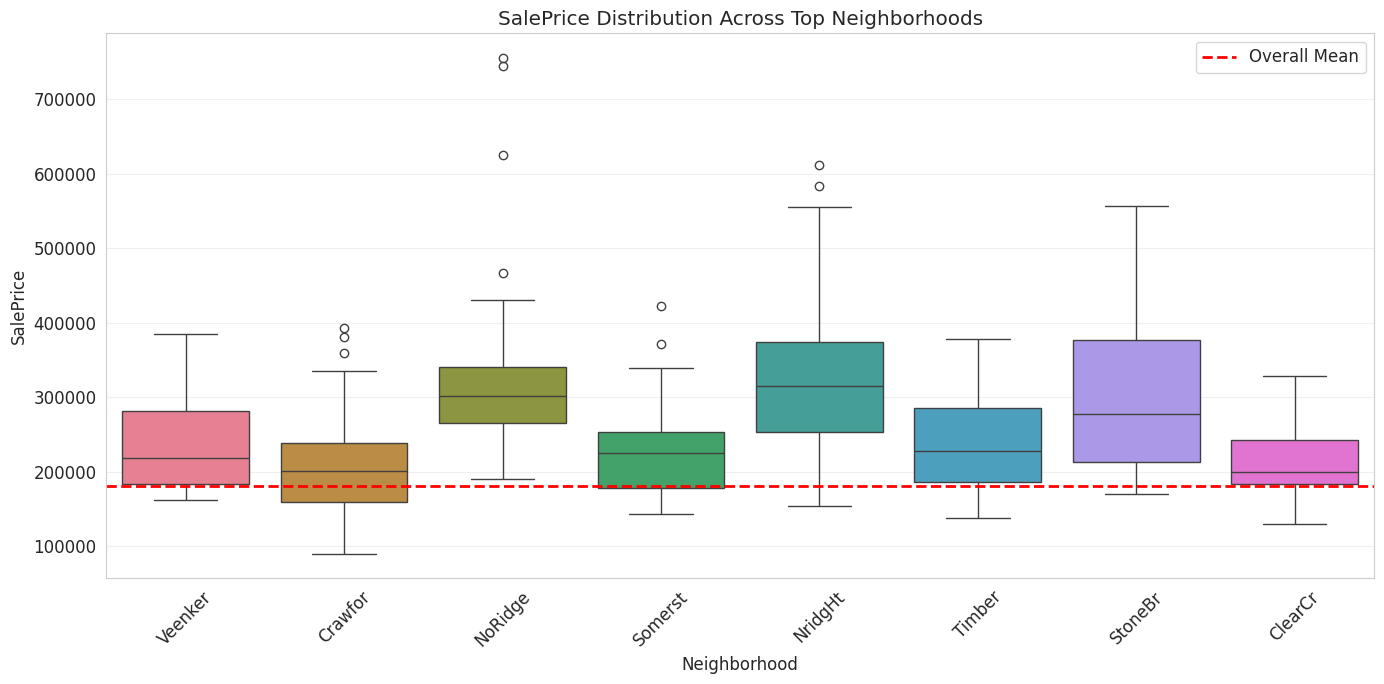

In [15]:
top_neighborhoods = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[df['Neighborhood'].isin(top_neighborhoods)],
    x='Neighborhood',
    y='SalePrice',
    palette='husl'
)

plt.axhline(
    df['SalePrice'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Overall Mean'
)

plt.xticks(rotation=45)

plt.title("SalePrice Distribution Across Top Neighborhoods")

plt.legend()

plt.tight_layout()

plt.savefig("w3_boxplot_neighborhoods.png", dpi=150)

plt.show()

### Chart 6  Heatmap

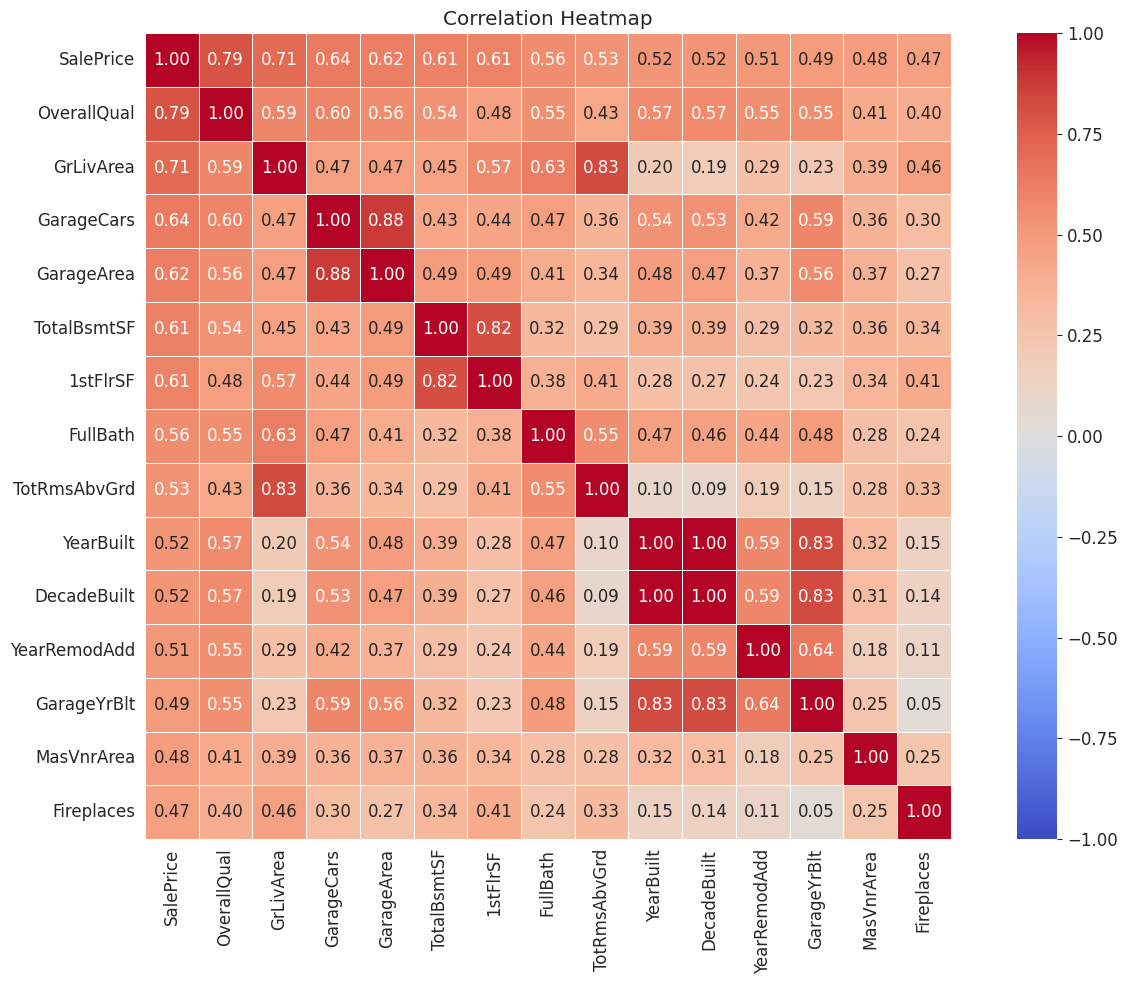

In [16]:
top15_features = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

corr_matrix = df[top15_features].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("w3_heatmap.png", dpi=150)

plt.show()

## Step 6 PairPlot & FacetGrid

### STEP 6 ADVANCED SEABORN VISUALIZATION



### Chart 7 PairPlot

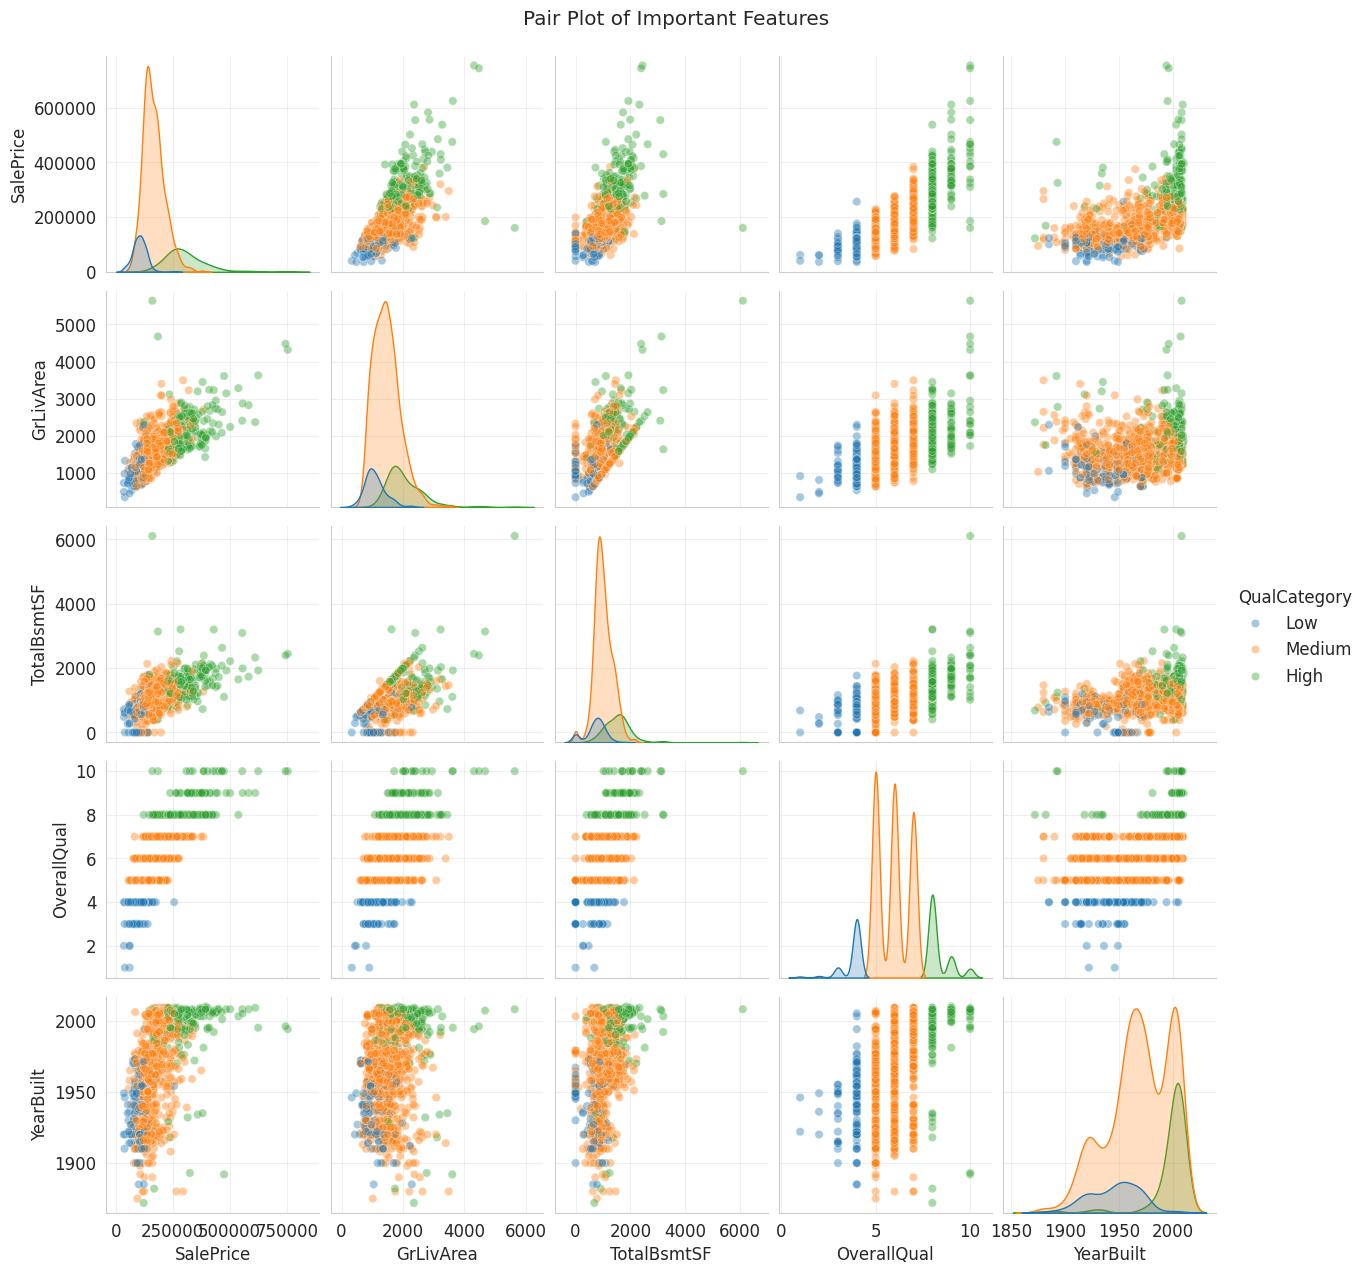

In [17]:
# Create Quality Bins
df['QualCategory'] = pd.cut(
    df['OverallQual'],
    bins=[0,4,7,10],
    labels=['Low','Medium','High']
)

pairplot_cols = [
    'SalePrice',
    'GrLivArea',
    'TotalBsmtSF',
    'OverallQual',
    'YearBuilt',
    'QualCategory'
]

pair_plot = sns.pairplot(
    df[pairplot_cols],
    hue='QualCategory',
    diag_kind='kde',
    plot_kws=dict(alpha=0.4)
)

pair_plot.fig.suptitle(
    "Pair Plot of Important Features",
    y=1.02
)

pair_plot.savefig("w3_pairplot.png", dpi=150)

plt.show()

### Chart 8  FacetGrid

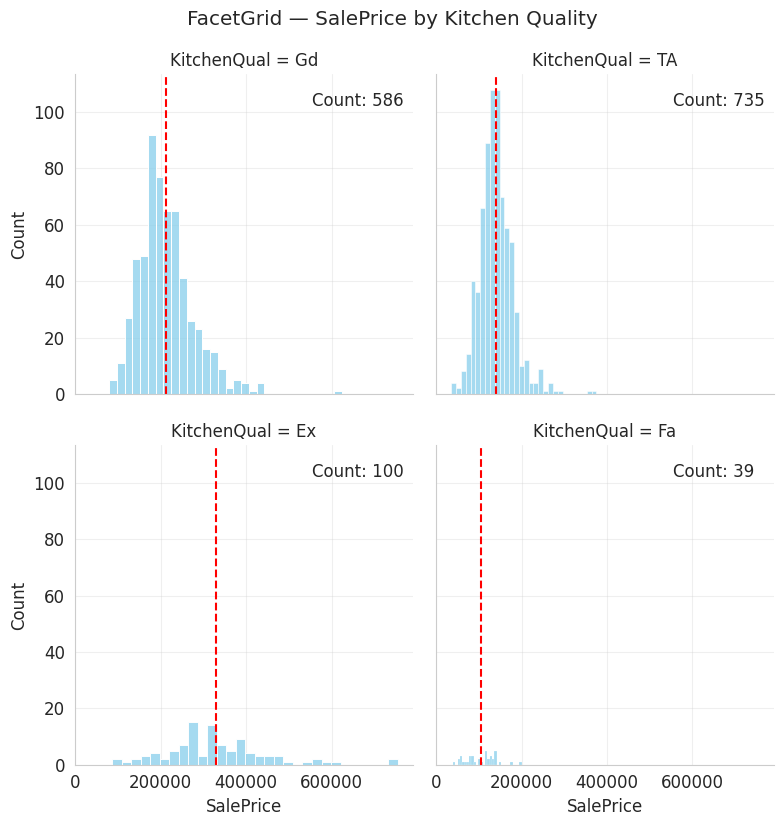

In [18]:
g = sns.FacetGrid(
    df,
    col='KitchenQual',
    col_wrap=2,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x='SalePrice',
    bins=30,
    color='skyblue'
)

# Add Mean Line
for ax, quality in zip(g.axes.flat, df['KitchenQual'].dropna().unique()):
    
    subset = df[df['KitchenQual'] == quality]

    mean_price = subset['SalePrice'].mean()

    ax.axvline(
        mean_price,
        color='red',
        linestyle='--'
    )

    ax.text(
        0.7,
        0.9,
        f'Count: {len(subset)}',
        transform=ax.transAxes
    )

g.fig.suptitle(
    "FacetGrid — SalePrice by Kitchen Quality",
    y=1.03
)

g.savefig("w3_facetgrid.png", dpi=150)

plt.show()

## Step 7 Feature Creation (8 Engineered Features)

### (a) TotalSF
 Combines basement + first floor + second floor
 to represent total usable property area.

In [19]:
df['TotalSF'] = (
    df['TotalBsmtSF'] +
    df['1stFlrSF'] +
    df['2ndFlrSF']
)

### (b) TotalBaths
 Weighted bathroom count gives better estimate
 of total bathroom utility in the house.

In [20]:
df['TotalBaths'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

### (c) HouseAge
 Measures house age at time of sale.
 Older houses may have lower market value.


In [21]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

### (d) RemodelAge
 Indicates years since last remodeling.
 Recently remodeled houses often sell higher.

In [22]:
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

### (e) HasRemodeled
 Binary feature identifying whether a house
 has been remodeled or not.

In [23]:
df['HasRemodeled'] = (
    df['YearBuilt'] != df['YearRemodAdd']
).astype(int)

### (f) QualCond
 Interaction between quality and condition
 captures overall structural desirability.


In [24]:
df['QualCond'] = (
    df['OverallQual'] *
    df['OverallCond']
)

### (g) PricePerSF
 Price density metric showing value per
 square foot of total living area.

In [25]:
df['PricePerSF'] = np.where(
    df['TotalSF'] > 0,
    df['SalePrice'] / df['TotalSF'],
    0
)

### (h) IsNewHouse
 Identifies houses built within last 5 years
 before the sale date.




In [26]:
df['IsNewHouse'] = (
    df['YearBuilt'] >= (df['YrSold'] - 5)
).astype(int)

### New Feature List

In [27]:
new_features = [
    'TotalSF',
    'TotalBaths',
    'HouseAge',
    'RemodelAge',
    'HasRemodeled',
    'QualCond',
    'PricePerSF',
    'IsNewHouse'
]

### Statistics

In [28]:
print("Summary Statistics of Engineered Features:")
print(df[new_features].describe())

Summary Statistics of Engineered Features:
            TotalSF   TotalBaths     HouseAge   RemodelAge  HasRemodeled  \
count   1460.000000  1460.000000  1460.000000  1460.000000   1460.000000   
mean    2567.048630     2.210616    36.547945    22.950000      0.476712   
std      821.714421     0.785399    30.250152    20.640653      0.499629   
min      334.000000     1.000000     0.000000    -1.000000      0.000000   
25%     2009.500000     2.000000     8.000000     4.000000      0.000000   
50%     2474.000000     2.000000    35.000000    14.000000      0.000000   
75%     3004.000000     2.500000    54.000000    41.000000      1.000000   
max    11752.000000     6.000000   136.000000    60.000000      1.000000   

          QualCond   PricePerSF   IsNewHouse  
count  1460.000000  1460.000000  1460.000000  
mean     33.864384    69.944000     0.212329  
std       9.219624    15.397065     0.409096  
min       1.000000    13.614704     0.000000  
25%      30.000000    60.461553     0

In [29]:
print("\nFirst 10 Rows:")
print(df[new_features].head(10))


First 10 Rows:
   TotalSF  TotalBaths  HouseAge  RemodelAge  HasRemodeled  QualCond  \
0     2566         3.5         5           5             0        35   
1     2524         2.5        31          31             0        48   
2     2706         3.5         7           6             1        35   
3     2473         2.0        91          36             1        35   
4     3343         3.5         8           8             0        40   
5     2158         2.5        16          14             1        25   
6     3380         3.0         3           2             1        40   
7     3197         3.5        36          36             0        42   
8     2726         2.0        77          58             1        35   
9     2068         2.0        69          58             1        30   

   PricePerSF  IsNewHouse  
0   81.254871           1  
1   71.909667           0  
2   82.594235           0  
3   56.611403           0  
4   74.783129           0  
5   66.265060          

## Step 8 Correlation Analysis of Engineered Features

###  Correlation with SalePrice

In [30]:
corr_all = (
    df.corr(numeric_only=True)['SalePrice']
    .sort_values(ascending=False)
)

### Top 20 Positive Correlations

In [31]:
print("\nTop 20 Features Correlated with SalePrice:")
print(corr_all.head(20))


Top 20 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
DecadeBuilt     0.515824
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
IsNewHouse      0.433543
Name: SalePrice, dtype: float64


### Bottom 10 Correlations

In [32]:
print("\nBottom 10 Features Correlated with SalePrice:")
print(corr_all.tail(10))


Bottom 10 Features Correlated with SalePrice:
Id              -0.021917
HasRemodeled    -0.021933
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
RemodelAge      -0.509079
HouseAge        -0.523350
Name: SalePrice, dtype: float64


### Horizontal Bar Chart

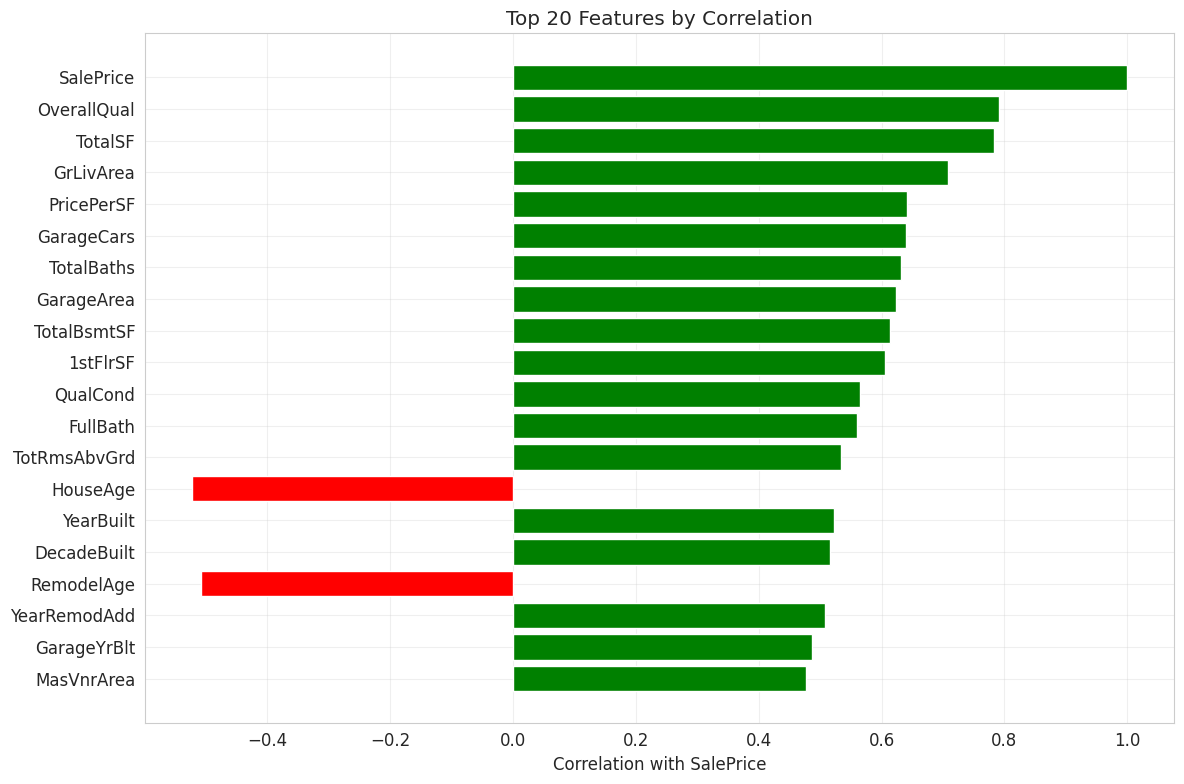

In [33]:
top20 = corr_all.abs().sort_values(
    ascending=False
).head(20)

actual_corr = corr_all[top20.index]

colors = [
    'green' if val > 0 else 'red'
    for val in actual_corr
]

plt.figure(figsize=(12, 8))

plt.barh(
    actual_corr.index,
    actual_corr.values,
    color=colors
)

plt.xlabel("Correlation with SalePrice")
plt.title("Top 20 Features by Correlation")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Several engineered features entered the top correlated features list, especially:

- TotalSF
- TotalBaths
- QualCond
- PricePerSF

This demonstrates the importance of feature engineering in machine learning. 
Engineered features combine domain knowledge with raw data to create more informative variables that better explain the target variable. 
Instead of relying only on original columns, feature engineering helps models capture hidden relationships and improve predictive performance.

## Step 9 Categorical Variable Analysis & Encoding Strategy

In [34]:
categorical_cols = df.select_dtypes(include='object').columns

encoding_strategy = {}

for col in categorical_cols:

    print("\n" + "="*60)
    print(f"Column: {col}")

    
    # Unique Categories
    unique_count = df[col].nunique()

    print(f"\nUnique Categories: {unique_count}")

    
    # Value Counts
    print("\nValue Counts:")
    print(df[col].value_counts())


    # Mean SalePrice Per Category
    print("\nMean SalePrice Per Category:")

    print(
        df.groupby(col)['SalePrice']
        .mean()
        .sort_values(ascending=False)
    )

    
    # Missing Ratio
    missing_ratio = df[col].isnull().mean()

    # Dominant Ratio
    dominant_ratio = (
        df[col].value_counts(normalize=True)
        .max()
    )

    
    # Decide Encoding Strategy
    ordinal_keywords = [
        'Qual',
        'Cond',
        'QC',
        'Exposure',
        'Finish'
    ]

    if (
        missing_ratio > 0.5 or
        dominant_ratio > 0.95
    ):
        strategy = 'drop'

    elif any(k in col for k in ordinal_keywords):
        strategy = 'label_encode'

    elif unique_count <= 10:
        strategy = 'onehot_encode'

    else:
        strategy = 'frequency_encode'

    encoding_strategy[col] = strategy

    print(f"\nEncoding Strategy: {strategy}")


# Final Encoding Strategy Table
strategy_df = pd.DataFrame({
    'Column': encoding_strategy.keys(),
    'Strategy': encoding_strategy.values()
})

print("\nEncoding Decision Table:")
print(strategy_df)


Column: MSZoning

Unique Categories: 5

Value Counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Mean SalePrice Per Category:
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64

Encoding Strategy: onehot_encode

Column: Street

Unique Categories: 2

Value Counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Mean SalePrice Per Category:
Street
Pave    181130.538514
Grvl    130190.500000
Name: SalePrice, dtype: float64

Encoding Strategy: drop

Column: Alley

Unique Categories: 2

Value Counts:
Alley
Grvl    50
Pave    41
Name: count, dtype: int64

Mean SalePrice Per Category:
Alley
Pave    168000.585366
Grvl    122219.080000
Name: SalePrice, dtype: float64

Encoding Strategy: drop

Column: LotShape

Unique Categories: 4

Value Counts:
LotShape
Reg    925
IR1    484
IR2     41
IR3     10

| Encoding Type | Reason |
|---|---|
| Label Encoding | Used for ordinal categorical variables where category order matters (Ex > Gd > TA > Fa > Po). |
| One-Hot Encoding | Used for nominal categories with small unique counts to avoid introducing false order. |
| Frequency Encoding | Used for high-cardinality nominal features like Neighborhood to reduce dimensionality. |
| Drop | Used for features with excessive missing values or nearly constant values that add little information. |

## Step 10 Apply All Encoding Strategies

In [35]:
print("Shape Before Encoding:")
print(df.shape)


# Label Encoding
quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0
}

quality_columns = [
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'GarageQual',
    'FireplaceQu'
]

for col in quality_columns:

    df[col] = (
        df[col]
        .fillna('NA')
        .map(quality_map)
    )


# Frequency Encoding
if 'Neighborhood' in df.columns:

    freq_map = (
        df['Neighborhood']
        .value_counts(normalize=True)
    )

    df['Neighborhood'] = (
        df['Neighborhood']
        .map(freq_map)
    )


# One-Hot Encoding
remaining_object_cols = df.select_dtypes(
    include='object'
).columns.tolist()

# Remove already handled columns
remaining_object_cols = [
    col for col in remaining_object_cols
    if col not in quality_columns
]

# Columns with <=10 unique values
ohe_cols = [
    col for col in remaining_object_cols
    if df[col].nunique() <= 10
]

df = pd.get_dummies(
    df,
    columns=ohe_cols,
    drop_first=True
)


# Encode Remaining Object Columns
remaining_object_cols = df.select_dtypes(
    include='object'
).columns

for col in remaining_object_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )


# Verification
print("\nShape After Encoding:")
print(df.shape)

print("\nRemaining Object Columns:")
print(df.select_dtypes(include='object').columns)

Shape Before Encoding:
(1460, 91)

Shape After Encoding:
(1460, 194)

Remaining Object Columns:
Index([], dtype='object')


## Step 11 Feature Scaling Comparison


Before Scaling:
        GrLivArea      TotalSF  OverallQual
mean  1527.401541  2583.476884     6.121575
std    524.432686   821.305316     1.367619

After Standard Scaling:
         GrLivArea       TotalSF   OverallQual
mean -1.307934e-16  1.429602e-16 -5.170902e-17
std   1.000428e+00  1.000428e+00  1.000428e+00

After MinMax Scaling:
      GrLivArea   TotalSF  OverallQual
mean   0.224831  0.197011     0.569064
std    0.098800  0.071931     0.151958

After Robust Scaling:
      GrLivArea   TotalSF  OverallQual
mean   0.084180  0.091210     0.060788
std    0.811501  0.837212     0.683810


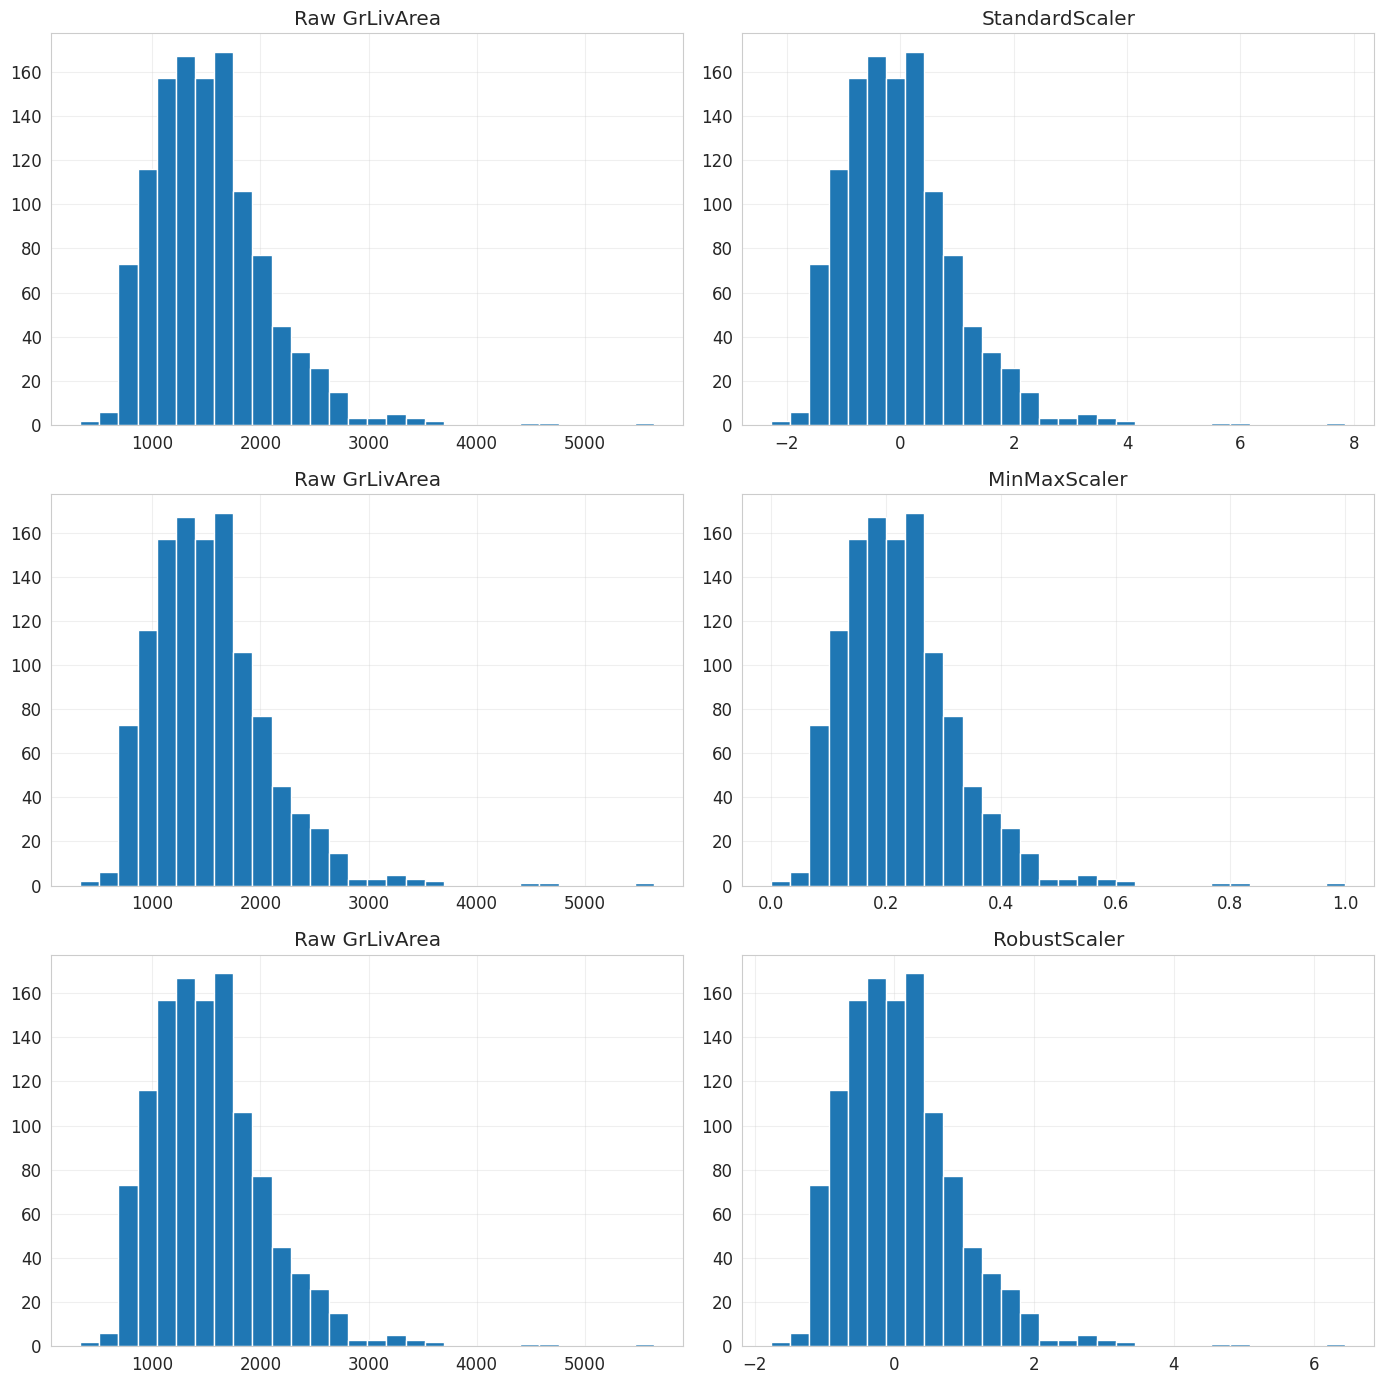

In [36]:
# Features & Target
X = df.drop('SalePrice', axis=1)

# Keep only numerical
X = X.select_dtypes(include=np.number)

y = df['SalePrice']


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Initialize Scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()


# Apply Scaling
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)


# Comparison Table
selected_features = ['GrLivArea', 'TotalSF', 'OverallQual']

print("\nBefore Scaling:")
print(X_train[selected_features].agg(['mean','std']))

print("\nAfter Standard Scaling:")
print(
    pd.DataFrame(
        X_train_standard,
        columns=X_train.columns
    )[selected_features].agg(['mean','std'])
)

print("\nAfter MinMax Scaling:")
print(
    pd.DataFrame(
        X_train_minmax,
        columns=X_train.columns
    )[selected_features].agg(['mean','std'])
)

print("\nAfter Robust Scaling:")
print(
    pd.DataFrame(
        X_train_robust,
        columns=X_train.columns
    )[selected_features].agg(['mean','std'])
)


# Histograms
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Raw
axes[0,0].hist(X_train['GrLivArea'], bins=30)
axes[0,0].set_title("Raw GrLivArea")

# Standard
axes[0,1].hist(
    pd.DataFrame(X_train_standard,
    columns=X_train.columns)['GrLivArea'],
    bins=30
)
axes[0,1].set_title("StandardScaler")

# Raw Again
axes[1,0].hist(X_train['GrLivArea'], bins=30)
axes[1,0].set_title("Raw GrLivArea")

# MinMax
axes[1,1].hist(
    pd.DataFrame(X_train_minmax,
    columns=X_train.columns)['GrLivArea'],
    bins=30
)
axes[1,1].set_title("MinMaxScaler")

# Raw Again
axes[2,0].hist(X_train['GrLivArea'], bins=30)
axes[2,0].set_title("Raw GrLivArea")

# Robust
axes[2,1].hist(
    pd.DataFrame(X_train_robust,
    columns=X_train.columns)['GrLivArea'],
    bins=30
)
axes[2,1].set_title("RobustScaler")

plt.tight_layout()

plt.show()

For Linear Regression in Week 4, StandardScaler is generally the best choice because it standardizes features around zero mean and unit variance, which improves gradient optimization and coefficient interpretation.

MinMaxScaler is useful when features must remain between 0 and 1, especially for neural networks.

RobustScaler is best when the dataset contains many outliers because it uses the median and interquartile range instead of mean and standard deviation.

For tree-based models like Random Forest or XGBoost, scaling is usually unnecessary because trees are scale-invariant.

## Step 12 Skewness Detection & Visualization

          Feature   Skewness   Severity
42        MiscVal  24.476794  Very High
41       PoolArea  14.828374  Very High
3         LotArea  12.207688  Very High
39      3SsnPorch  10.304342  Very High
20   LowQualFinSF   9.011341  Very High
27   KitchenAbvGr   4.488397  Very High
15     BsmtFinSF2   4.255261  Very High
40    ScreenPorch   4.122214  Very High
23   BsmtHalfBath   4.103403  Very High
35     GarageQual  -3.228583  Very High
38  EnclosedPorch   3.089872  Very High
11     MasVnrArea   2.669084  Very High
37    OpenPorchSF   2.364342  Very High
2     LotFrontage   2.163569  Very High
45      SalePrice   1.882876       High
47        TotalSF   1.776700       High
14     BsmtFinSF1   1.685503       High
36     WoodDeckSF   1.541376       High
17    TotalBsmtSF   1.524255       High
54     IsNewHouse   1.408303       High
1      MSSubClass   1.407657       High
18       1stFlrSF   1.376757       High
21      GrLivArea   1.366560       High
13       BsmtQual  -1.287571       High


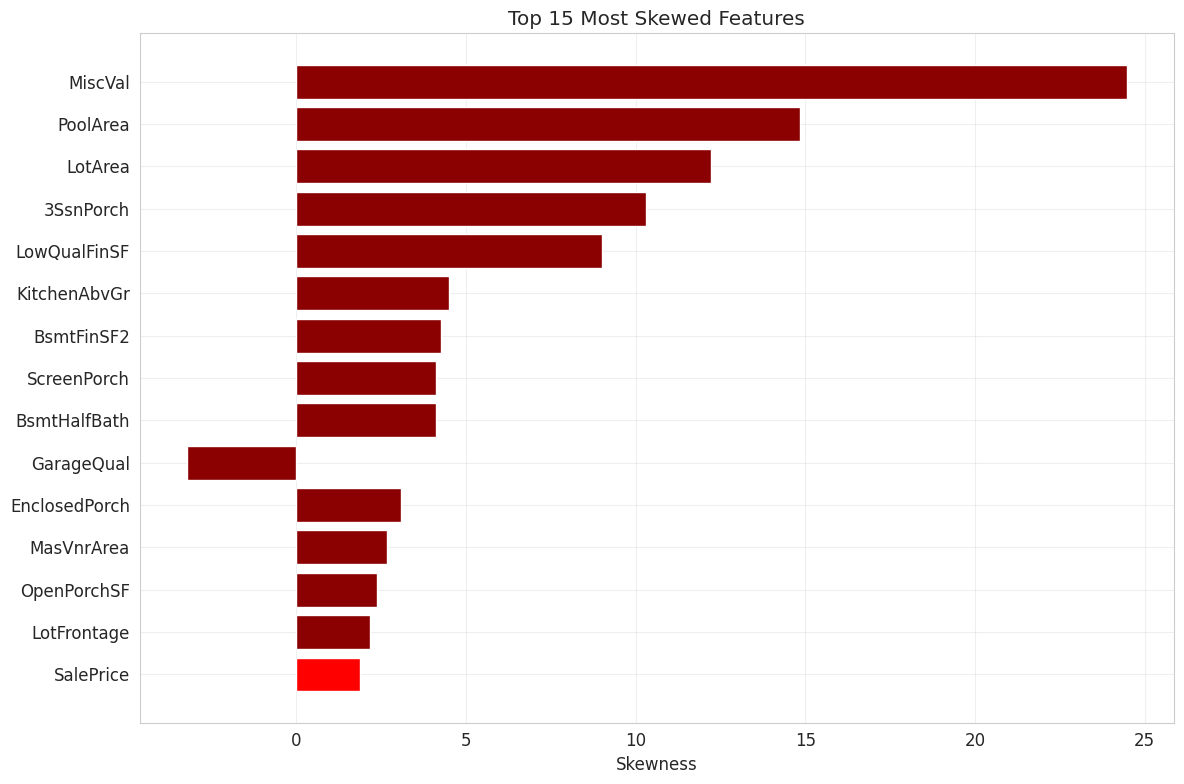

In [37]:
# Numerical Features
numerical_df = df.select_dtypes(include=np.number)

# Calculate Skewness
skewness = numerical_df.skew()

skew_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

# Absolute Skewness
skew_df['AbsSkew'] = skew_df['Skewness'].abs()


# Severity Classification
def classify_skew(x):

    if abs(x) < 0.5:
        return 'Normal'

    elif abs(x) < 1:
        return 'Moderate'

    elif abs(x) < 2:
        return 'High'

    else:
        return 'Very High'

skew_df['Severity'] = skew_df['Skewness'].apply(classify_skew)

# Sort by highest skew
skew_df = skew_df.sort_values(
    by='AbsSkew',
    ascending=False
)


# Print Table
print(skew_df[['Feature', 'Skewness', 'Severity']])


# Count Highly Skewed Features
high_skew_count = (
    skew_df['AbsSkew'] > 1
).sum()

total_numeric = len(skew_df)

percentage_high = (
    high_skew_count / total_numeric
) * 100

print("\nHighly Skewed Features:", high_skew_count)

print(
    f"Percentage Highly Skewed: {percentage_high:.2f}%"
)


# Top 15 Most Skewed Features
top15_skew = skew_df.head(15)

severity_colors = {
    'Normal': 'green',
    'Moderate': 'orange',
    'High': 'red',
    'Very High': 'darkred'
}

colors = [
    severity_colors[s]
    for s in top15_skew['Severity']
]

plt.figure(figsize=(12, 8))

plt.barh(
    top15_skew['Feature'],
    top15_skew['Skewness'],
    color=colors
)

plt.xlabel("Skewness")
plt.title("Top 15 Most Skewed Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Step 13 Apply Skewness Transformations

Highly Skewed Features:
['MSSubClass', 'LotFrontage', 'LotArea', 'Neighborhood', 'MasVnrArea', 'ExterQual', 'BsmtQual', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'GarageQual', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'IsNewHouse']

Original Skewness: 1.8828757597682129
Log1p Skewness: 0.12134661989685333
Sqrt Skewness: 0.9431527373310963
BoxCox Skewness: -0.008653002352916217


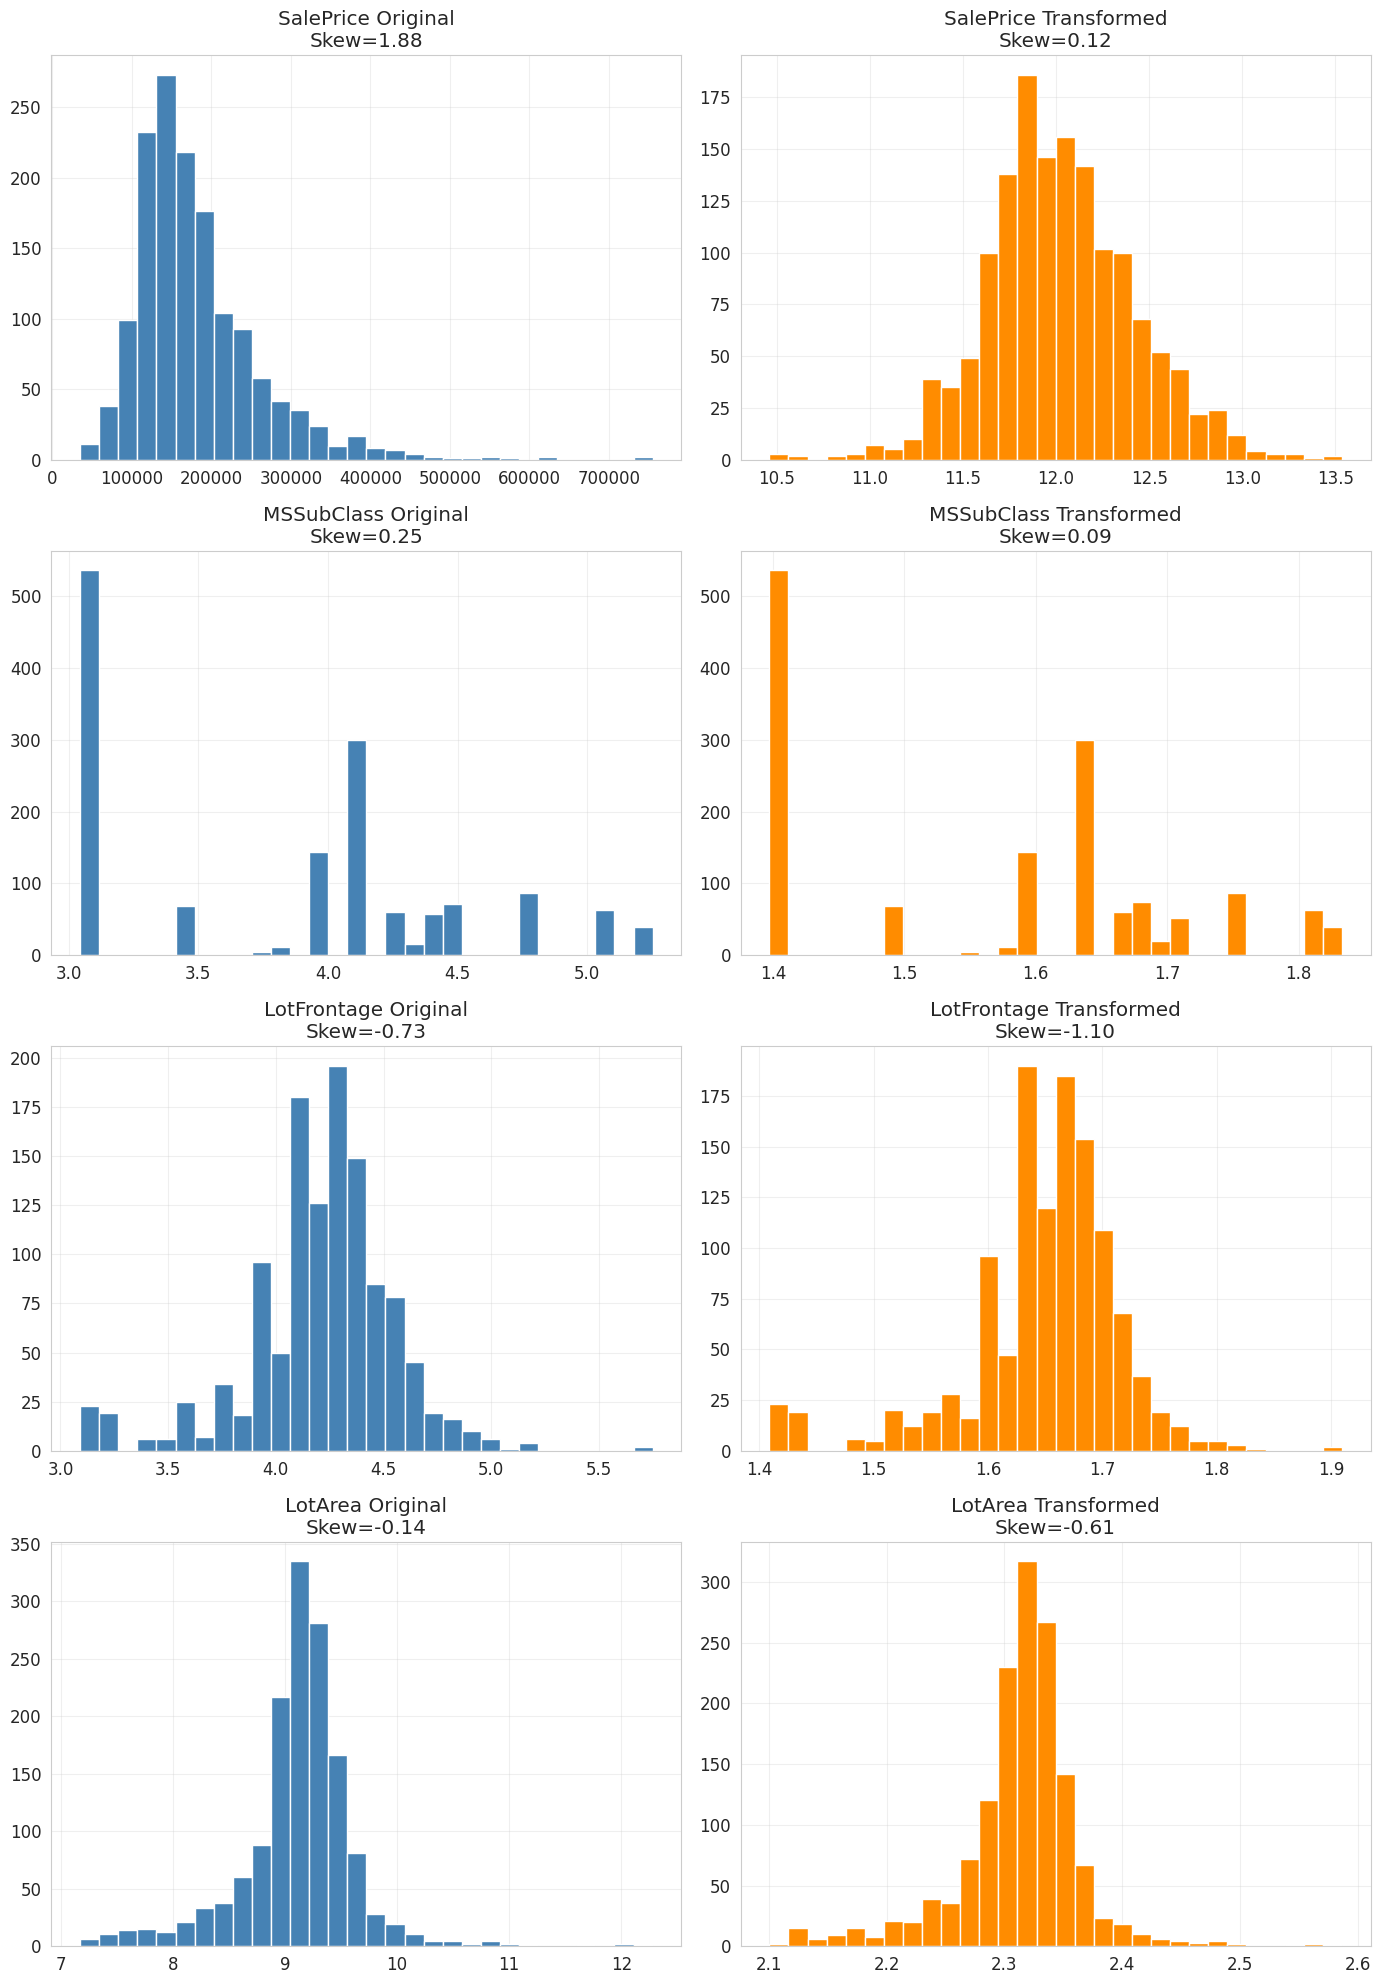

In [38]:
from scipy.stats import boxcox


# Identify Highly Skewed Features
numeric_cols = df.select_dtypes(include=np.number).columns

skew_values = df[numeric_cols].skew()

high_skew_features = skew_values[
    skew_values.abs() > 0.75
].index.tolist()

# Remove Target Variable
if 'SalePrice' in high_skew_features:
    high_skew_features.remove('SalePrice')

print("Highly Skewed Features:")
print(high_skew_features)


# Apply log1p Transformation
for col in high_skew_features:

    df[col] = np.log1p(df[col])


# SalePrice Transformations
saleprice_original = df['SalePrice']

saleprice_log = np.log1p(saleprice_original)

saleprice_sqrt = np.sqrt(saleprice_original)

# Box-Cox requires strictly positive values
saleprice_boxcox, lambda_boxcox = boxcox(
    saleprice_original
)


# Compare Skewness
print("\nOriginal Skewness:",
      saleprice_original.skew())

print("Log1p Skewness:",
      saleprice_log.skew())

print("Sqrt Skewness:",
      saleprice_sqrt.skew())

print("BoxCox Skewness:",
      pd.Series(saleprice_boxcox).skew())


# Save Best Transformation
df['SalePrice_transformed'] = saleprice_log


# Visualization
features_to_plot = [
    'SalePrice',
    high_skew_features[0],
    high_skew_features[1],
    high_skew_features[2]
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, feature in enumerate(features_to_plot):

    original = df[feature]

    transformed = np.log1p(original)

    # Original
    axes[i,0].hist(
        original,
        bins=30,
        color='steelblue',
        edgecolor='white'
    )

    axes[i,0].set_title(
        f"{feature} Original\nSkew={original.skew():.2f}"
    )

    # Transformed
    axes[i,1].hist(
        transformed,
        bins=30,
        color='darkorange',
        edgecolor='white'
    )

    axes[i,1].set_title(
        f"{feature} Transformed\nSkew={transformed.skew():.2f}"
    )

plt.tight_layout()

plt.show()

Among the tested transformations, log1p() produced the best balance between skewness reduction and interpretability for SalePrice.

Highly skewed features create instability in machine learning models because extreme values dominate the learning process. Transformations such as log1p compress large values and create distributions closer to normality, improving regression performance and reducing sensitivity to outliers.

## Step 14 Feature Selection

In [39]:
# Correlation-Based Selection
corr_target = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
)

top30_features = corr_target.head(30).index.tolist()

print("\nTop 30 Features:")
print(top30_features)


# Create Feature Subset
selected_df = df[top30_features].copy()

# Remove Target
if 'SalePrice' in selected_df.columns:
    feature_df = selected_df.drop(
        'SalePrice',
        axis=1
    )
else:
    feature_df = selected_df.copy()


# Variance Threshold
selector = VarianceThreshold(
    threshold=0.01
)

selector.fit(feature_df)

kept_columns = feature_df.columns[
    selector.get_support()
]

feature_df = feature_df[kept_columns]

print("\nAfter Variance Threshold:")
print(feature_df.shape)


# Remove Multicollinearity
corr_matrix = feature_df.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = []

for column in upper_triangle.columns:

    high_corr = upper_triangle[column] > 0.95

    if any(high_corr):

        correlated_feature = (
            upper_triangle[column]
            [high_corr]
            .index[0]
        )

        # Compare correlation with target
        col_corr = corr_target[column]
        corr_feat_corr = corr_target[correlated_feature]

        if col_corr < corr_feat_corr:
            to_drop.append(column)

        else:
            to_drop.append(correlated_feature)

# Remove duplicates
to_drop = list(set(to_drop))

feature_df.drop(
    columns=to_drop,
    inplace=True,
    errors='ignore'
)

print("\nDropped Multicollinear Features:")
print(to_drop)


# Final Feature Set
final_features = feature_df.columns.tolist()

print("\nFinal Selected Features:")
print(final_features)


# Feature Information
final_info = pd.DataFrame({
    'Feature': final_features,
    'CorrelationWithSalePrice': [
        corr_target[f]
        for f in final_features
    ],
    'DataType': [
        feature_df[f].dtype
        for f in final_features
    ]
})

print("\nFinal Feature Information:")
print(final_info)


# Reduction Statistics
original_feature_count = (
    df.shape[1] - 1
)

remaining_features = len(final_features)

eliminated = (
    original_feature_count -
    remaining_features
)

elimination_percentage = (
    eliminated / original_feature_count
) * 100

print("\nRemaining Features:",
      remaining_features)

print(
    f"Eliminated Percentage: "
    f"{elimination_percentage:.2f}%"
)


Top 30 Features:
['SalePrice', 'SalePrice_transformed', 'OverallQual', 'TotalSF', 'GrLivArea', 'ExterQual', 'KitchenQual', 'PricePerSF', 'GarageCars', 'TotalBaths', 'GarageArea', '1stFlrSF', 'QualCond', 'FullBath', 'TotRmsAbvGrd', 'HouseAge', 'YearBuilt', 'FireplaceQu', 'DecadeBuilt', 'RemodelAge', 'YearRemodAdd', 'Foundation_PConc', 'GarageYrBlt', 'Fireplaces', 'BsmtQual', 'BsmtFinType1_GLQ', 'IsNewHouse', 'OpenPorchSF', 'MasVnrArea', 'GarageFinish_Unf']

After Variance Threshold:
(1460, 29)

Dropped Multicollinear Features:
['YearRemodAdd', 'YearBuilt', 'DecadeBuilt']

Final Selected Features:
['SalePrice_transformed', 'OverallQual', 'TotalSF', 'GrLivArea', 'ExterQual', 'KitchenQual', 'PricePerSF', 'GarageCars', 'TotalBaths', 'GarageArea', '1stFlrSF', 'QualCond', 'FullBath', 'TotRmsAbvGrd', 'HouseAge', 'FireplaceQu', 'RemodelAge', 'Foundation_PConc', 'GarageYrBlt', 'Fireplaces', 'BsmtQual', 'BsmtFinType1_GLQ', 'IsNewHouse', 'OpenPorchSF', 'MasVnrArea', 'GarageFinish_Unf']

Final Fea

## Step 15 Reusable Feature Engineering Functions

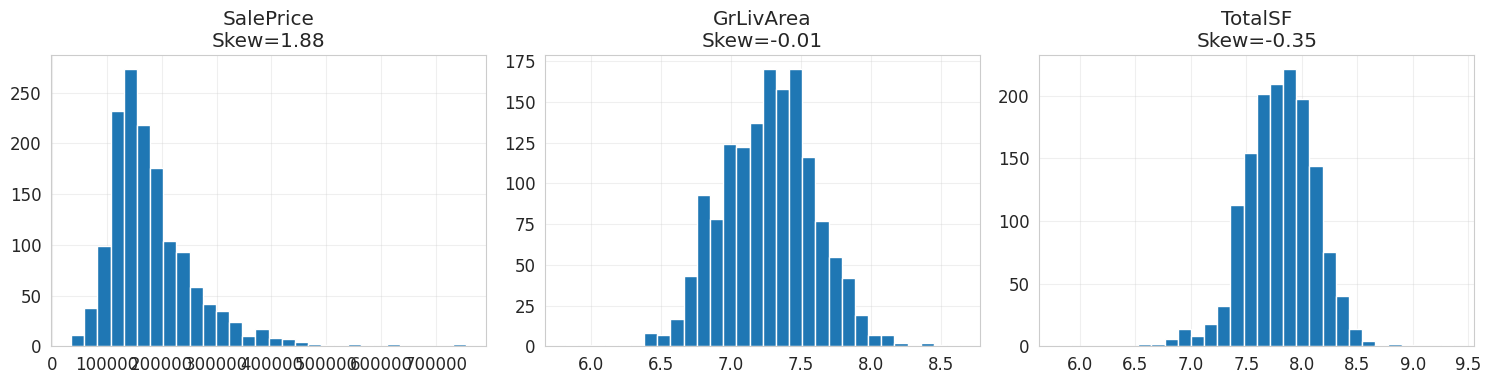


Encoded KitchenQual:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: KitchenQual, dtype: float64

Mapping Used:
{'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}

Scaled Train Shape:
(1168, 54)

Scaler Used:
StandardScaler()


In [40]:
from typing import List, Tuple


# Function 1
def visualize_distributions(
    df: pd.DataFrame,
    cols: List[str],
    n_cols: int = 3
) -> None:
    """
    Creates a histogram grid for selected columns
    and displays skewness in titles.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe

    cols : List[str]
        Columns to visualize

    n_cols : int
        Number of subplot columns
    """

    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5*n_cols, 4*n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(cols):

        skewness = df[col].skew()

        axes[i].hist(
            df[col],
            bins=30,
            edgecolor='white'
        )

        axes[i].set_title(
            f"{col}\nSkew={skewness:.2f}"
        )

    plt.tight_layout()
    plt.show()


# Function 2
def encode_quality_column(
    series: pd.Series,
    quality_map: dict = None
) -> Tuple[pd.Series, dict]:
    """
    Encodes ordinal quality columns.

    Parameters
    ----------
    series : pd.Series
        Categorical quality column

    quality_map : dict
        Optional mapping dictionary

    Returns
    -------
    encoded_series : pd.Series
        Encoded numeric series

    mapping : dict
        Mapping used
    """

    if quality_map is None:

        quality_map = {
            'Ex': 5,
            'Gd': 4,
            'TA': 3,
            'Fa': 2,
            'Po': 1,
            'NA': 0
        }

    encoded = (
        series.fillna('NA')
        .map(quality_map)
    )

    return encoded, quality_map


# Function 3
def full_scaling_pipeline(
    X_train,
    X_test,
    method: str = 'standard'
):
    """
    Fits scaler on training data and transforms
    both train and test sets.

    Parameters
    ----------
    X_train : array-like
    X_test : array-like
    method : str

    Returns
    -------
    X_train_scaled
    X_test_scaled
    scaler
    """

    if method == 'standard':
        scaler = StandardScaler()

    elif method == 'minmax':
        scaler = MinMaxScaler()

    elif method == 'robust':
        scaler = RobustScaler()

    else:
        raise ValueError(
            "Method must be "
            "'standard', 'minmax', or 'robust'"
        )

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    return (
        X_train_scaled,
        X_test_scaled,
        scaler
    )


# Function Calls
# Function 1
visualize_distributions(
    df,
    ['SalePrice', 'GrLivArea', 'TotalSF']
)

# Function 2
encoded_col, used_map = encode_quality_column(
    df['KitchenQual']
)

print("\nEncoded KitchenQual:")
print(encoded_col.head())

print("\nMapping Used:")
print(used_map)

# Function 3
scaled_train, scaled_test, scaler_obj = (
    full_scaling_pipeline(
        X_train,
        X_test,
        method='standard'
    )
)

print("\nScaled Train Shape:")
print(scaled_train.shape)

print("\nScaler Used:")
print(scaler_obj)

## Step 16 Final Professional Dashboard

/tmp/ipykernel_57/2833509733.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


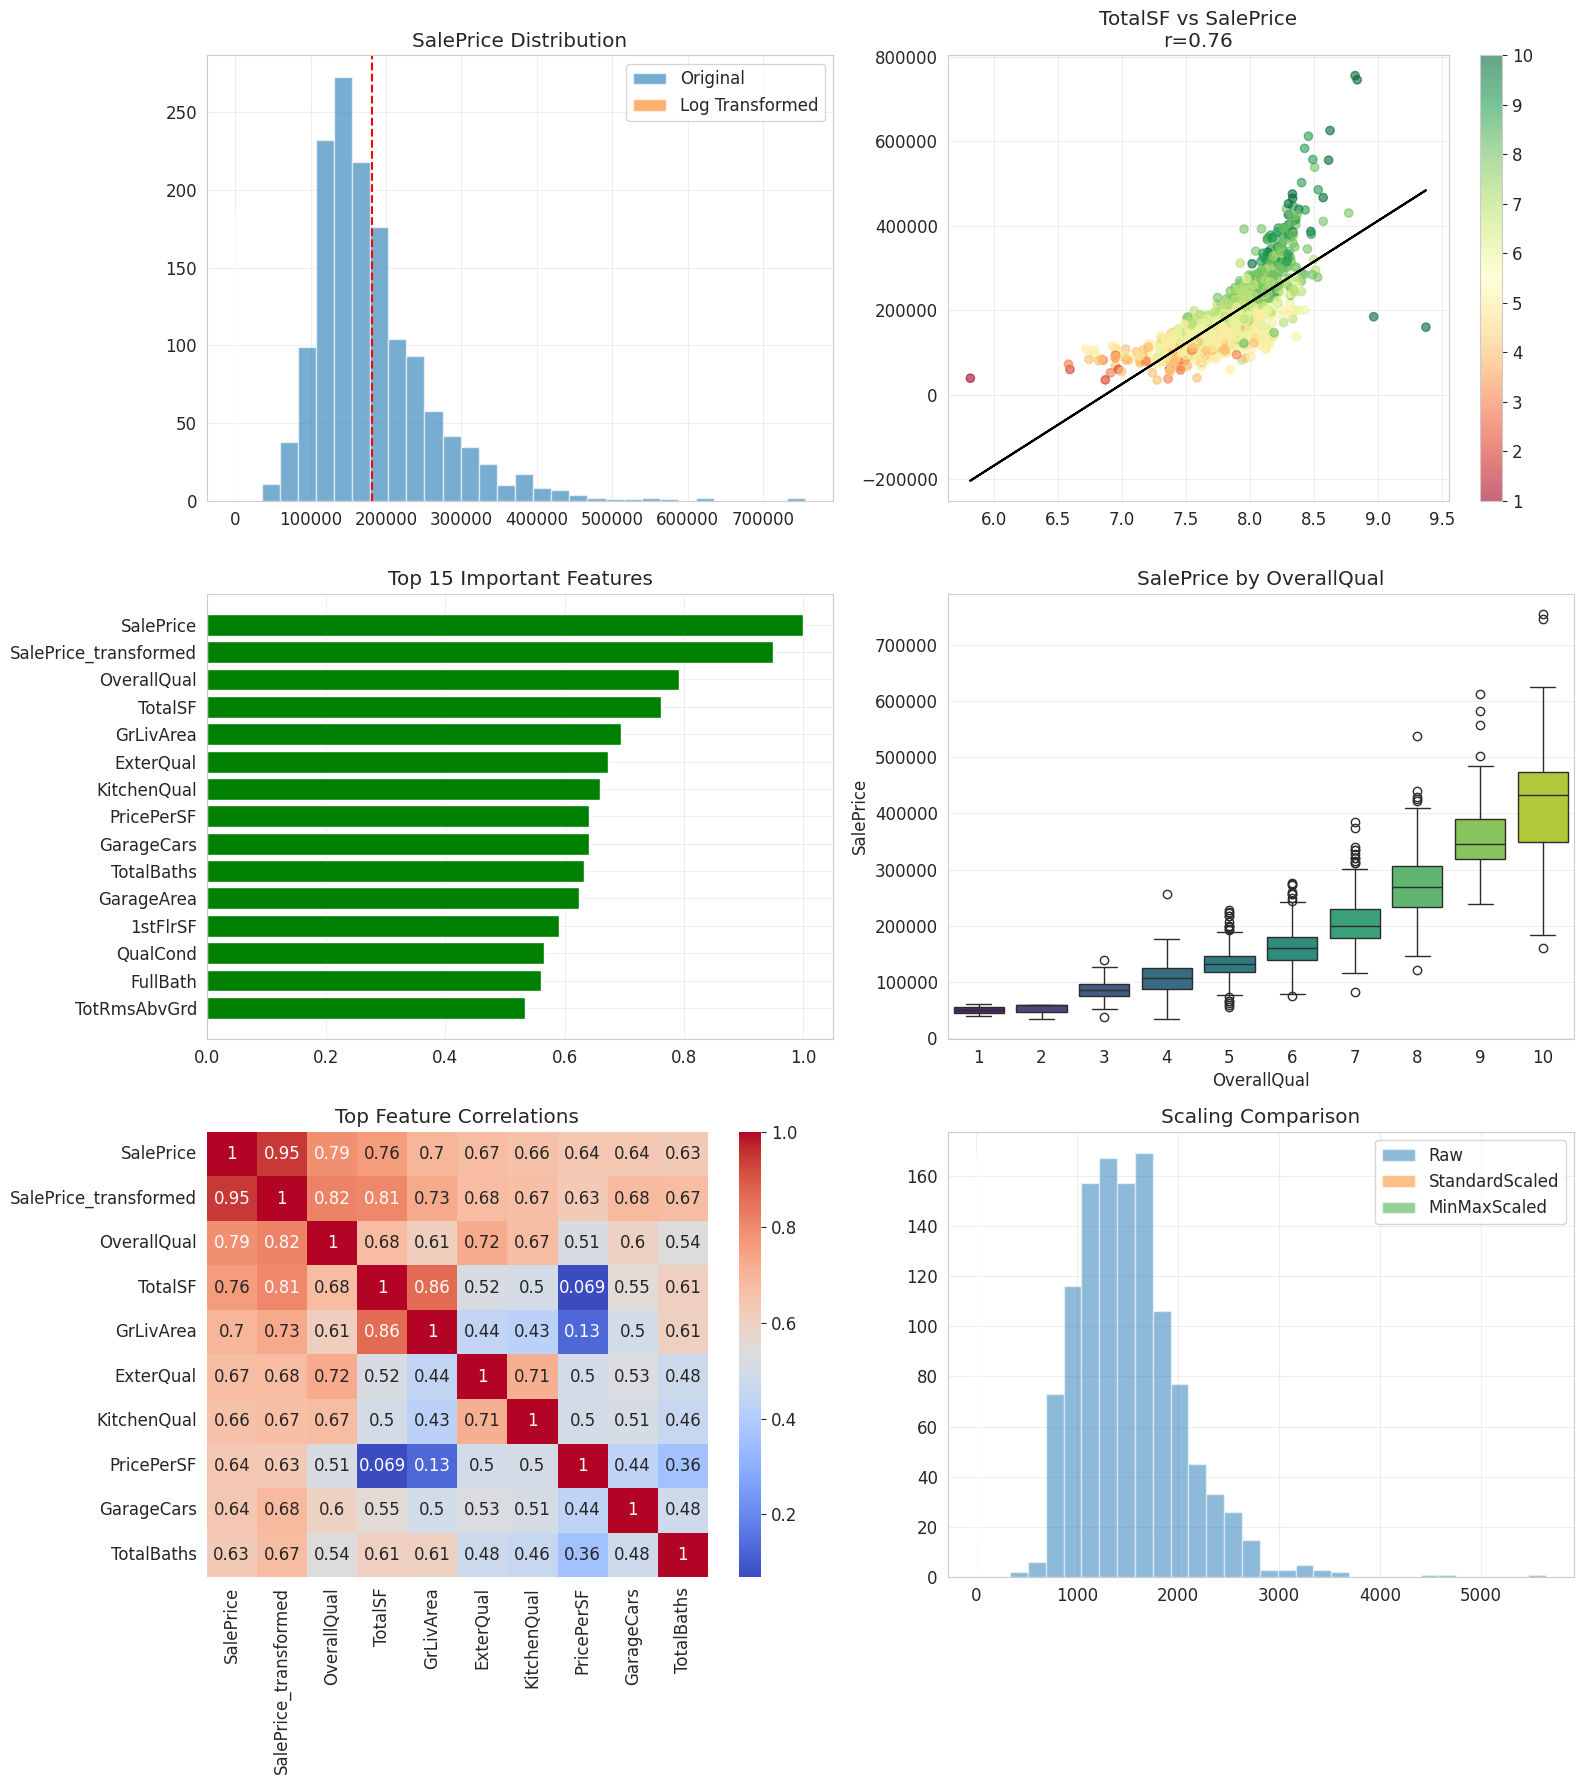

In [41]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18)
)


# Chart 1
# SalePrice Before & After Log
axes[0,0].hist(
    df['SalePrice'],
    bins=30,
    alpha=0.6,
    label='Original'
)

axes[0,0].hist(
    np.log1p(df['SalePrice']),
    bins=30,
    alpha=0.6,
    label='Log Transformed'
)

axes[0,0].axvline(
    df['SalePrice'].mean(),
    color='red',
    linestyle='--'
)

axes[0,0].set_title(
    "SalePrice Distribution"
)

axes[0,0].legend()


# Chart 2
# Scatter Plot
scatter = axes[0,1].scatter(
    df['TotalSF'],
    df['SalePrice'],
    c=df['OverallQual'],
    cmap='RdYlGn',
    alpha=0.6
)

z = np.polyfit(
    df['TotalSF'],
    df['SalePrice'],
    1
)

p = np.poly1d(z)

axes[0,1].plot(
    df['TotalSF'],
    p(df['TotalSF']),
    color='black'
)

r = df['TotalSF'].corr(
    df['SalePrice']
)

axes[0,1].set_title(
    f"TotalSF vs SalePrice\nr={r:.2f}"
)

fig.colorbar(
    scatter,
    ax=axes[0,1]
)


# Chart 3
# Top 15 Features
top15 = (
    df.corr(numeric_only=True)['SalePrice']
    .sort_values(key=np.abs,
                 ascending=False)
    .head(15)
)

colors = [
    'green' if x > 0 else 'red'
    for x in top15.values
]

axes[1,0].barh(
    top15.index,
    top15.values,
    color=colors
)

axes[1,0].invert_yaxis()

axes[1,0].set_title(
    "Top 15 Important Features"
)


# Chart 4
# Boxplots by OverallQual
sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df,
    palette='viridis',
    ax=axes[1,1]
)

axes[1,1].set_title(
    "SalePrice by OverallQual"
)


# Chart 5
# Heatmap
top10_features = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

corr_top10 = df[top10_features].corr()

sns.heatmap(
    corr_top10,
    annot=True,
    cmap='coolwarm',
    ax=axes[2,0]
)

axes[2,0].set_title(
    "Top Feature Correlations"
)


# Chart 6
# Scaling Comparison
axes[2,1].hist(
    X_train['GrLivArea'],
    bins=30,
    alpha=0.5,
    label='Raw'
)

axes[2,1].hist(
    pd.DataFrame(
        X_train_standard,
        columns=X_train.columns
    )['GrLivArea'],
    bins=30,
    alpha=0.5,
    label='StandardScaled'
)

axes[2,1].hist(
    pd.DataFrame(
        X_train_minmax,
        columns=X_train.columns
    )['GrLivArea'],
    bins=30,
    alpha=0.5,
    label='MinMaxScaled'
)

axes[2,1].set_title(
    "Scaling Comparison"
)

axes[2,1].legend()


# Final Layout
plt.tight_layout()

plt.savefig(
    "week3_dashboard.png",
    dpi=150
)

plt.show()